# Trabalho de DL - Detector de SPAM (RNN) - G13

### 1. Importar bibliotecas

In [1]:
# Importação das bibliotecas
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 2. Carregar a base

In [2]:
# carrega e arruma a base
!wget http://www.razer.net.br/datasets/spam.csv

df = pd.read_csv("spam.csv", encoding="ISO-8859-1")

df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
df.columns = ["labels", "data"]
df["b_labels"] = df["labels"].map({"ham": 0, "spam": 1})

y = df["b_labels"].values

--2026-07-03 22:39:23--  http://www.razer.net.br/datasets/spam.csv
Resolving www.razer.net.br (www.razer.net.br)... 178.128.150.229
Connecting to www.razer.net.br (www.razer.net.br)|178.128.150.229|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.razer.net.br/datasets/spam.csv [following]
--2026-07-03 22:39:23--  https://www.razer.net.br/datasets/spam.csv
Connecting to www.razer.net.br (www.razer.net.br)|178.128.150.229|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [application/octet-stream]
Saving to: ‘spam.csv.1’

spam.csv.1          100%[===================>] 491.86K   513KB/s    in 1.0s    

2026-07-03 22:39:26 (513 KB/s) - ‘spam.csv.1’ saved [503663/503663]



### 3. Separação de Treino e Teste

In [3]:
# Separa treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    df["data"],
    y,
    test_size=0.33,
    random_state=42
)

"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv"

### 4. Acerta a Tokenização

In [11]:
# Tokenização
num_words = 20000

tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(x_train)

sequences_train = tokenizer.texts_to_sequences(x_train)
sequences_test = tokenizer.texts_to_sequences(x_test)

word2index = tokenizer.word_index
V = len(word2index)

print(f"{V} tokens")

7259 tokens


### 5. Acerta o tamanho das sequências (padding)

In [12]:
# Padding
data_train = pad_sequences(sequences_train)
T = data_train.shape[1]

data_test = pad_sequences(sequences_test, maxlen=T)

print("data_train.shape:", data_train.shape)
print("data_test.shape:", data_test.shape)

data_train.shape: (3733, 121)
data_test.shape: (1839, 121)


### x. Dataset Pytorch

In [13]:
class SpamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
train_dataset = SpamDataset(data_train, y_train)
test_dataset = SpamDataset(data_test, y_test)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False)

### 6. Definição do modelo

In [15]:
class SpamRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size + 1,
            embedding_dim=embedding_dim
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)
        x = hidden[-1]

        x = self.fc(x)
        x = self.sigmoid(x)

        return x.squeeze()

In [16]:
D = 20  # embedding size
M = 5   # hidden size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpamRNN(V, D, M).to(device)
print(model)

SpamRNN(
  (embedding): Embedding(7260, 20)
  (lstm): LSTM(20, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 7. Função de perda e otimizador

In [17]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

### 8. Compila e treina o modelo

In [18]:
epochs = 5

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):

    # Treinamento
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (outputs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validação
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            preds = (outputs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = running_loss / len(test_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"loss={train_loss:.4f} | "
        f"acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

Epoch 1/5 | loss=0.7037 | acc=0.4466 | val_loss=0.5345 | val_acc=0.8352
Epoch 2/5 | loss=0.4028 | acc=0.8669 | val_loss=0.3228 | val_acc=0.8728
Epoch 3/5 | loss=0.2775 | acc=0.8923 | val_loss=0.2534 | val_acc=0.8999
Epoch 4/5 | loss=0.2204 | acc=0.9242 | val_loss=0.2111 | val_acc=0.9277
Epoch 5/5 | loss=0.1807 | acc=0.9491 | val_loss=0.1814 | val_acc=0.9527


### 9. Exibe a perda e a acurácia

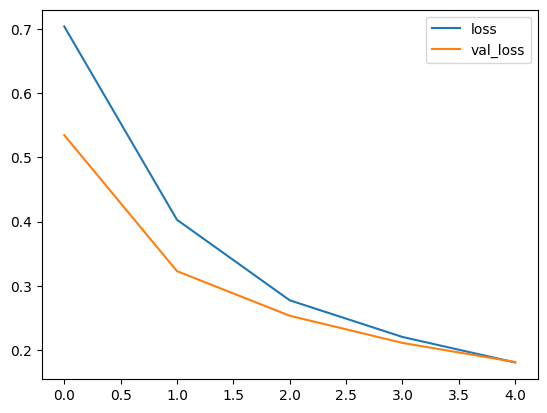

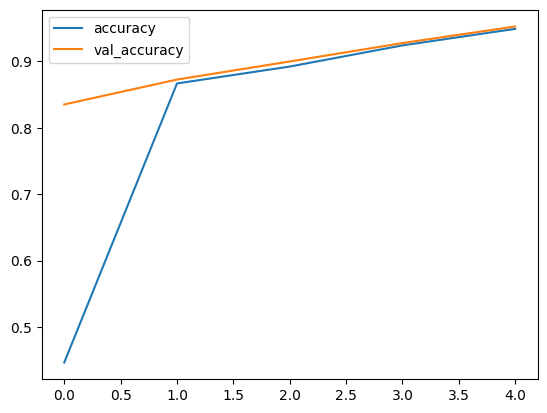

In [19]:
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.legend()
plt.show()

plt.plot(train_accs, label="accuracy")
plt.plot(val_accs, label="val_accuracy")
plt.legend()
plt.show()

### 10. Faz a predição de um dado novo

In [ ]:
texto = "Is your car dirty? Discover our new product. Free for all. Click the link."

seq_texto = tokenizer.texts_to_sequences([texto])
data_texto = pad_sequences(seq_texto, maxlen=T)

x = torch.tensor(data_texto, dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    pred = model(x).item()

print(pred)
print("SPAM" if pred >= 0.5 else "OK")

0.6817054152488708
SPAM
